In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df=pd.read_csv(r"C:\Users\Asus\Documents\used_cars_mock (1).xls")

In [3]:
df.sample(15)

,car_id,brand,model,year,mileage,fuel_type,transmission,sale_month,zip_prefix,price
602,603,Fiat,Model A,2015,96596.0,Petrol,Manual,9,1,8452
6609,6610,BMW,Model A,2020,62733.0,Petrol,Automatic,1,30,8180
4157,4158,Hyundai,Model A,2025,0.0,Diesel,Automatic,4,1,25569
4031,4032,Hyundai,Model B,2019,105144.0,Diesel,Automatic,10,1,12531
626,627,Hyundai,Model A,2022,12404.0,Petrol,Manual,11,10,13672
3523,3524,Ford,Model B,2010,196772.0,Petrol,Automatic,1,30,780
9631,9632,Dacia,Model B,2024,0.0,Hybrid,Manual,10,1,18068
3289,3290,BMW,Model C,2016,100497.0,Diesel,Automatic,12,30,500
3859,3860,Honda,Model C,2025,2996.0,Petrol,Automatic,11,1,28218
2827,2828,Hyundai,Model A,2009,207520.0,Petrol,Automatic,7,1,500


h0-the more the reputation of the brand the more the price.

h0-the latest model are updated with many features so the price may go high

h0-the latest year in which the car is made if affects its price as if the buyer will buy the 2020 model it would be cheap as compared to the latest one.

h0-transmission- if it is hybrid can be high priced.

h0-sale month- can affect the price.

In [4]:
df['brand'].value_counts()

brand
Toyota      1498
Honda       1192
Mercedes    1013
Ford         999
BMW          993
Hyundai      986
VW           944
Audi         836
Fiat         821
Dacia        718
Name: count, dtype: int64

In [5]:
df['model'].value_counts()           #  data is clean 

model
Model B    3441
Model C    3289
Model A    3270
Name: count, dtype: int64

In [6]:
df['year'].value_counts()

year
2025    2886
2021     837
2023     812
2024     810
2022     801
2020     800
2018     318
2015     306
2016     303
2019     300
2017     292
2007     115
2008     115
2005     114
2012     110
2003     110
2006     108
2013     105
2010     102
2001     102
2011      98
2000      95
2004      95
2002      91
2014      88
2009      86
2030       1
Name: count, dtype: int64

In [7]:
df['fuel_type'].value_counts()

fuel_type
Petrol    6969
Diesel    2050
Hybrid     980
XYZ          1
Name: count, dtype: int64

In [8]:
df['transmission'].value_counts()  # data is clean 

transmission
Automatic    5957
Manual       4043
Name: count, dtype: int64

In [9]:
df['sale_month'].value_counts()    # no anomalies found

sale_month
12    1245
1      837
3      817
7      816
11     809
10     806
5      803
2      789
9      789
8      781
4      754
6      754
Name: count, dtype: int64

In [10]:
df['zip_prefix'].value_counts()

zip_prefix
30    2975
1     2900
20    2082
10    2043
Name: count, dtype: int64

In [11]:
df['price'].value_counts()

price
500      886
21952      5
9369       4
17375      4
3398       4
        ... 
24343      1
25388      1
10913      1
17991      1
4710       1
Name: count, Length: 7876, dtype: int64

In [12]:
df['price'].describe()

count     10000.000000
mean      15278.148600
std       13725.370724
min           0.000000
25%        6761.500000
50%       15852.000000
75%       23125.000000
max      999999.000000
Name: price, dtype: float64

# Quality of the dataset :
- mileage= negative value, missing values,0.
- year= year greater than 2026 i.e=2030
- fuel type= random name other than petrol , hybrid and disel,i.e XYZ
- price=unrealstic value like 500,0

In [13]:
df.isnull().sum()

car_id            0
brand             0
model             0
year              0
mileage         306
fuel_type         0
transmission      0
sale_month        0
zip_prefix        0
price             0
dtype: int64

# Year

In [14]:
df['year'].dtype    # checking if all values are in int or not.

dtype('int64')

In [15]:
df['year'].unique()

array([2020, 2030, 2025, 2023, 2015, 2005, 2002, 2017, 2016, 2022, 2021,
       2019, 2013, 2004, 2006, 2009, 2024, 2012, 2003, 2018, 2008, 2014,
       2007, 2000, 2011, 2010, 2001], dtype=int64)

In [16]:
# as we can see 2030 is the unrealistic year.so removing that year.

In [17]:
df = df[df['year'] != 2030]

In [18]:
df['year'].unique()

array([2020, 2025, 2023, 2015, 2005, 2002, 2017, 2016, 2022, 2021, 2019,
       2013, 2004, 2006, 2009, 2024, 2012, 2003, 2018, 2008, 2014, 2007,
       2000, 2011, 2010, 2001], dtype=int64)

# mileage

In [19]:
df['mileage'].value_counts()

mileage
0.0         1595
250000.0     455
75000.0        7
43006.0        3
5309.0         3
            ... 
23896.0        1
51832.0        1
202167.0       1
225233.0       1
88837.0        1
Name: count, Length: 7410, dtype: int64

In [20]:
df[df['mileage']<0]

,car_id,brand,model,year,mileage,fuel_type,transmission,sale_month,zip_prefix,price
2,3,Audi,Model C,2025,-500.0,Petrol,Automatic,12,1,29629


as we can see mileage column has a negative value removing it,but it also has unrealistic value i.e 0 and count is also very high,so we would be imputing it with the most apt value

In [21]:
df=df[df['mileage']>=0]
df[df['mileage']<0]               # the negative value has been removed.

,car_id,brand,model,year,mileage,fuel_type,transmission,sale_month,zip_prefix,price


In [22]:
df['mileage'].describe()

count      9693.000000
mean      62042.978438
std       71547.687740
min           0.000000
25%        7777.000000
50%       35799.000000
75%       87774.000000
max      250000.000000
Name: mileage, dtype: float64

imputing it with median as in this case it is the apt one,because mean i.e 62042 is pulled up by the huge values like 250000, and is not a proper representer of the data,so median is apt here,as it is not affected by the extremes

In [23]:
df.loc[df['mileage'] == 0, 'mileage'] = None    #  CONVERTING  0 to nan.

df['mileage'].fillna(df['mileage'].median(), inplace=True)    # imputing it with median.

C:\Users\Asus\AppData\Local\Temp\ipykernel_8580\1156860876.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['mileage'].fillna(df['mileage'].median(), inplace=True)    # imputing it with median.


In [25]:
df.isnull().sum()

car_id          0
brand           0
model           0
year            0
mileage         0
fuel_type       0
transmission    0
sale_month      0
zip_prefix      0
price           0
dtype: int64

# fuel type

In [26]:
df['fuel_type'].value_counts()

fuel_type
Petrol    6770
Diesel    1981
Hybrid     941
XYZ          1
Name: count, dtype: int64

In [27]:
#  unknown XYZ in the column,removing it

In [28]:
df=df[df['fuel_type'] != 'XYZ']

In [29]:
df['fuel_type'].value_counts()           # XYZ has been remvoed .

fuel_type
Petrol    6770
Diesel    1981
Hybrid     941
Name: count, dtype: int64

# price

In [30]:
df['price'].describe()

count      9692.000000
mean      15261.159513
std       13835.627065
min           0.000000
25%        6728.750000
50%       15839.500000
75%       23118.500000
max      999999.000000
Name: price, dtype: float64

In [31]:
# min value 0 unrealistic

In [32]:
df[df['price']>50000]

,car_id,brand,model,year,mileage,fuel_type,transmission,sale_month,zip_prefix,price
0,1,Honda,Model A,2020,50757.0,Petrol,Manual,7,30,999999


In [33]:
# mostly all values are below 50000, so this one seems exceptions ,removing it. 

In [34]:
df=df[df['price'] != 999999]
df[df['price']>50000]                       # removed

,car_id,brand,model,year,mileage,fuel_type,transmission,sale_month,zip_prefix,price


In [35]:
df['price'].unique()

array([    0,   500, 21820, ..., 20601, 10563,  4710], dtype=int64)

In [36]:
df[['price', 'year', 'brand']].head(10)

,price,year,brand
4,0,2015,Dacia
5,500,2015,VW
6,500,2005,BMW
7,21820,2025,Ford
8,21380,2023,Mercedes
9,33616,2025,BMW
10,500,2002,Toyota
11,33231,2025,Audi
12,20673,2025,Hyundai
13,6814,2017,Toyota


In [37]:
df['price'].value_counts()

price
500      862
21952      5
21008      4
17375      4
3398       4
        ... 
17991      1
25042      1
26456      1
18090      1
4710       1
Name: count, Length: 7660, dtype: int64

In [38]:
df=df[df['price']!=0]                # price with zero row has been removed
df[['price', 'year', 'brand']].head(10)

,price,year,brand
5,500,2015,VW
6,500,2005,BMW
7,21820,2025,Ford
8,21380,2023,Mercedes
9,33616,2025,BMW
10,500,2002,Toyota
11,33231,2025,Audi
12,20673,2025,Hyundai
13,6814,2017,Toyota
14,9107,2016,VW


In [39]:
# now there are 862 cars with price 500 its unrealistic , so will fill it with median.

In [40]:
df.loc[df['price'] == 500, 'price'] = None
df['price'].fillna(df['price'].median(), inplace=True)

C:\Users\Asus\AppData\Local\Temp\ipykernel_8580\3776897326.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['price'].fillna(df['price'].median(), inplace=True)


In [41]:
df['price'].value_counts()

price
17277.0    862
21952.0      5
17375.0      4
21008.0      4
9369.0       4
          ... 
10913.0      1
17991.0      1
25042.0      1
26456.0      1
4710.0       1
Name: count, Length: 7659, dtype: int64

In [42]:
df.loc[df['price'] == 500, 'price']            #  no row with the car price with 500 

Series([], Name: price, dtype: float64)

In [43]:
df.loc[df['price'] < 5000, 'price'].count()

1149

In [44]:
df=df[df['price'] >700] 

In [45]:
df['price'].describe()

count     9641.000000
mean     16735.123120
std       8332.819211
min        702.000000
25%      10171.000000
50%      17277.000000
75%      23155.000000
max      38875.000000
Name: price, dtype: float64

# depreciated task 

In [46]:
current_year = 2026
df['age'] = current_year - df['year']

In [47]:
def depreciated_value(price, age):
    value = price
    
    for i in range(age):
        if i < 5:
            value *= 0.85
        else:
            value *= 0.90
            
    return value

In [48]:
df['depreciated_price'] = df.apply(
    lambda x: depreciated_value(x['price'], x['age']),
    axis=1
)

In [49]:
df['price_diff'] = df['price'] - df['depreciated_price']

In [50]:
df.sample(10)

,car_id,brand,model,year,mileage,fuel_type,transmission,sale_month,zip_prefix,price,age,depreciated_price,price_diff
3841,3842,Honda,Model C,2003,250000.0,Diesel,Manual,2,10,17277.0,23,1150.609967,16126.390033
414,415,VW,Model C,2024,20894.0,Petrol,Manual,2,10,22119.0,2,15980.977500,6138.022500
50,51,VW,Model C,2025,17114.0,Petrol,Automatic,3,30,22442.0,1,19075.700000,3366.300000
7761,7762,BMW,Model B,2008,215751.0,Petrol,Automatic,3,1,17277.0,18,1948.568082,15328.431918
5749,5750,Mercedes,Model A,2024,4041.0,Petrol,Manual,12,20,21715.0,2,15689.087500,6025.912500
9654,9655,Toyota,Model A,2022,22490.0,Petrol,Manual,7,20,9344.0,4,4877.626400,4466.373600
6854,6855,Honda,Model B,2001,250000.0,Petrol,Automatic,9,30,2128.0,25,114.793274,2013.206726
6762,6763,Mercedes,Model A,2015,104509.0,Petrol,Automatic,9,30,4148.0,11,978.111653,3169.888347
4587,4588,Mercedes,Model C,2013,148746.0,Diesel,Automatic,4,30,4957.0,13,946.789914,4010.210086
7012,7013,Honda,Model A,2019,68648.0,Petrol,Automatic,4,10,14435.0,7,5187.957811,9247.042189


In [51]:
df['age'].value_counts()

age
1     2793
5      805
3      788
2      786
4      781
6      777
8      307
7      290
11     288
10     287
9      281
19     112
18     111
21     107
14     106
23     106
20     103
13     100
25      94
16      93
15      92
22      91
26      90
24      87
12      84
17      82
Name: count, dtype: int64

In [52]:
# the age of car greater thatn 15 is high risk + low value.

# in this data the data is patani kya hi hai, in case if the data would have been relastic and meaningful than -

- if price_diff > 0= car is overpriced
- if price_diff < 0=car is underpriced
- if price_diff =0  car price is somewhat fair

# univariate analysis

# Price

Skewness: -0.08924617149558436


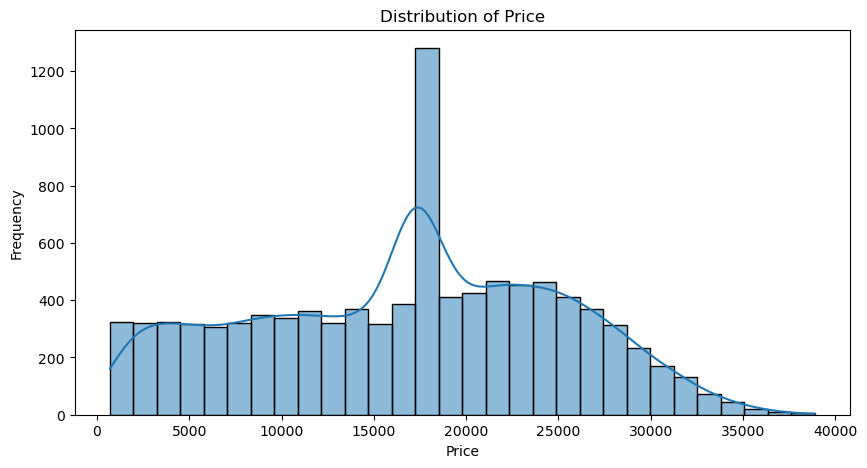

In [53]:
print("Skewness:", df['price'].skew())

# Histogram
plt.figure(figsize=(10,5))
sns.histplot(df['price'], bins=30, kde=True)
plt.title("Distribution of Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [54]:
df['price'].describe()

count     9641.000000
mean     16735.123120
std       8332.819211
min        702.000000
25%      10171.000000
50%      17277.000000
75%      23155.000000
max      38875.000000
Name: price, dtype: float64

- approximate symmetric not perfectly symmetric, massive spike somewhat near 17000-18000,can be a popular model.

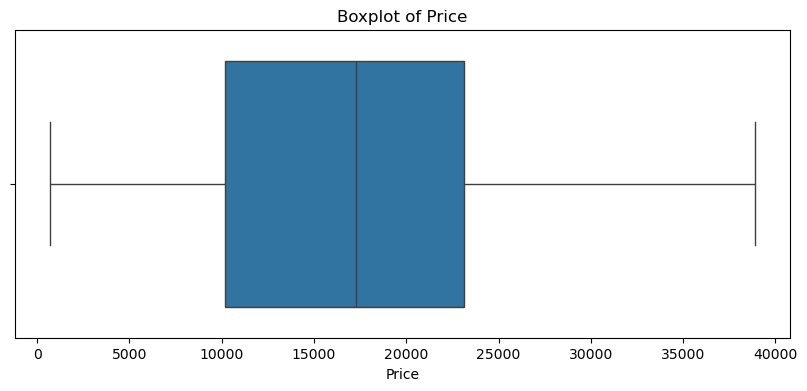

In [56]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df['price'])
plt.title("Boxplot of Price")
plt.xlabel("Price")
plt.show()


- Most car prices are concentrated between **10,000 and 23,000**.
- Median price is around **17,000–18,000**, indicating the typical used car price range.
- No extreme outliers are visible, suggesting the price column is relatively clean.

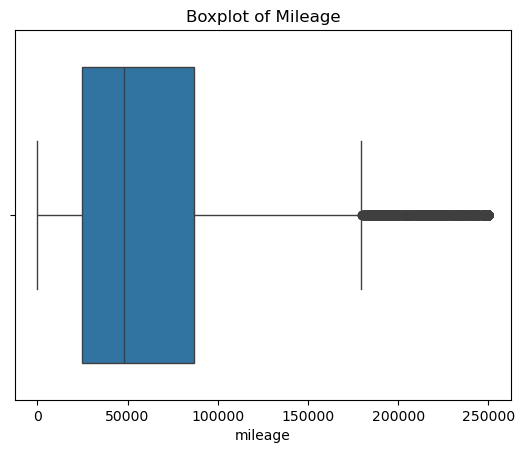

In [80]:
sns.boxplot(x=df["mileage"])
plt.title("Boxplot of Mileage")
plt.show()

In [81]:
# values above high wiskers considered as outliers

In [82]:
Q1 = df["mileage"].quantile(0.25)
Q3 = df["mileage"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["mileage"] < lower) | (df["mileage"] > upper)]

print("Lower Limit:", lower)
print("Upper Limit:", upper)
print("Number of Outliers:", len(outliers))

Lower Limit: -68075.5
Upper Limit: 179384.5
Number of Outliers: 1014


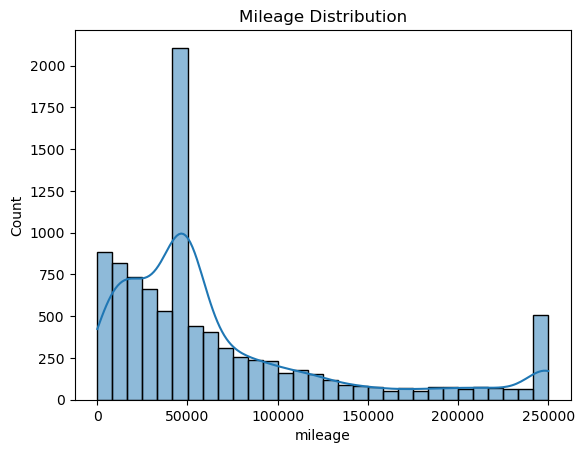

In [83]:
sns.histplot(df["mileage"], bins=30, kde=True)
plt.title("Mileage Distribution")
plt.show()

- Mileage is **positively skewed**, meaning most cars have lower mileage while fewer cars have very high mileage.
- Highest concentration of cars lies roughly between **20,000 to 60,000 km**.
- Strong peak near **45,000–50,000 km**, suggesting many cars are sold around this usage level.

In [84]:
print("Price Kurtosis:", df["price"].kurt())
print("Mileage Kurtosis:", df["mileage"].kurt())

Price Kurtosis: -0.8255812693772366
Mileage Kurtosis: 1.398143910344909


In [85]:
# mileage above 0 kurtosis indicates that data is higly concentrated and has extreme outliers.
# price below 0 indicates that data is spread out and lacks extreme outliers.

In [86]:
print("Price Variance:", df["price"].var())
print("Price Std Dev:", df["price"].std())

print("Mileage Variance:", df["mileage"].var())
print("Mileage Std Dev:", df["mileage"].std())

Price Variance: 69435875.9967688
Price Std Dev: 8332.819210613465
Mileage Variance: 4382575668.6982355
Mileage Std Dev: 66201.02468012285


In [87]:
# the more the variance the more the data is spread 

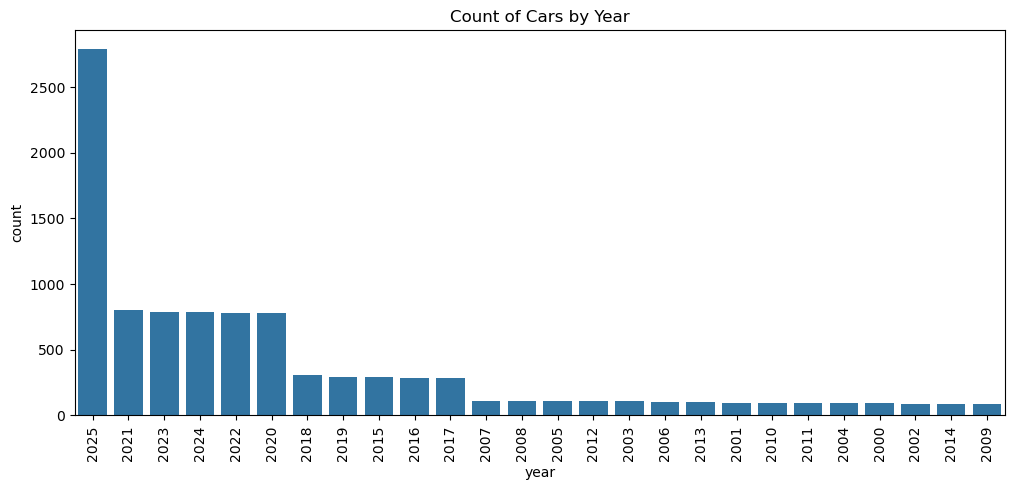

In [58]:
plt.figure(figsize=(12,5))
sns.countplot(x=df["year"], order=df["year"].value_counts().index)
plt.title("Count of Cars by Year")
plt.xticks(rotation=90)
plt.show()

 **most of the cars are of latest year**

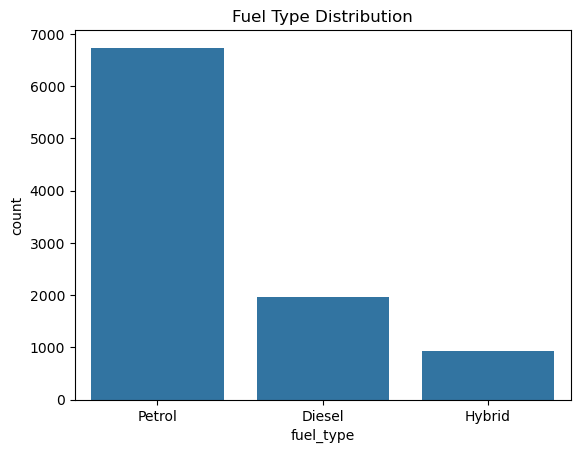

In [59]:
plt.figure()
sns.countplot(x=df["fuel_type"], order=df["fuel_type"].value_counts().index)
plt.title("Fuel Type Distribution")
plt.show()


In [60]:
# more petrol used car being listed

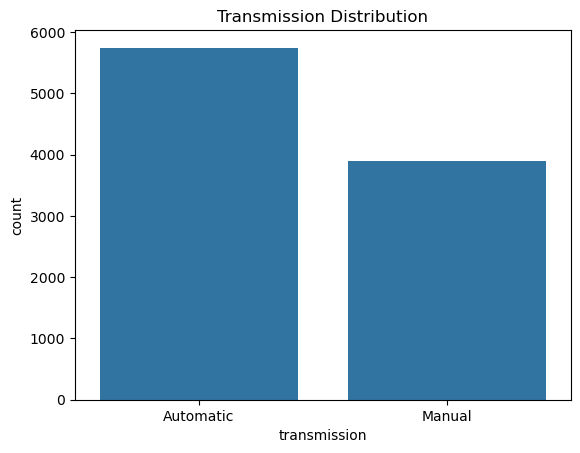

In [61]:
plt.figure()
sns.countplot(x=df["transmission"], order=df["transmission"].value_counts().index)
plt.title("Transmission Distribution")
plt.show()


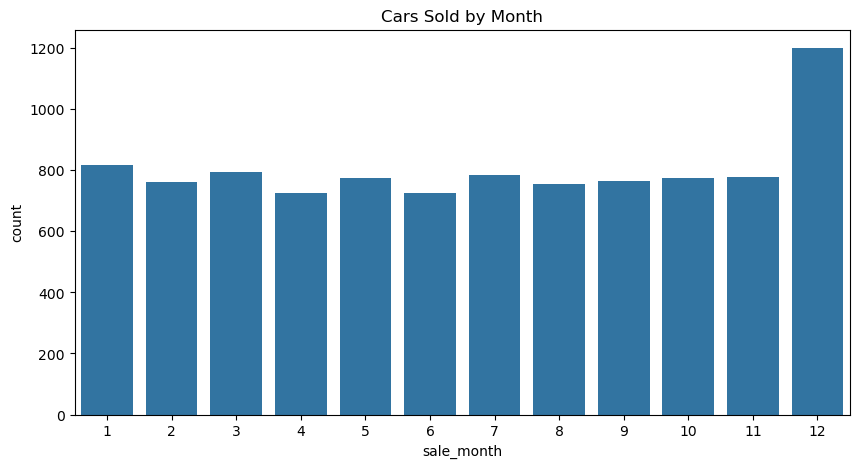

In [62]:
plt.figure(figsize=(10,5))
sns.countplot(x=df["sale_month"], order=sorted(df["sale_month"].unique()))
plt.title("Cars Sold by Month")
plt.show()

In [63]:
# most of the cars are sold in the month of december

# bivariate analysis

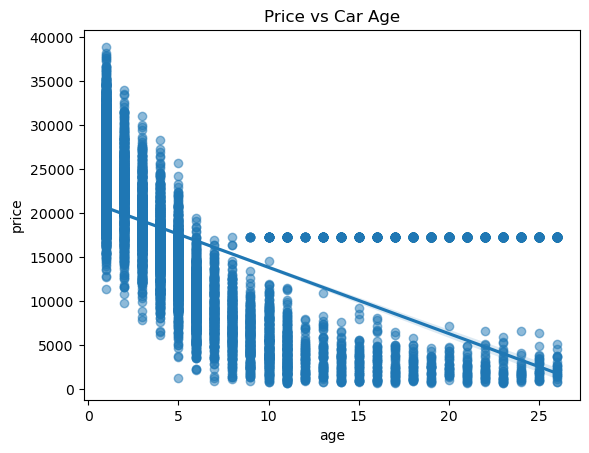

In [64]:
plt.figure()
sns.regplot(data=df, x="age", y="price", scatter_kws={"alpha":0.5})
plt.title("Price vs Car Age")
plt.show()

- Strong negative relationship between car age and price.
- As car age increases, resale price consistently declines.
- Newer cars (1–5 years old) have the highest prices.

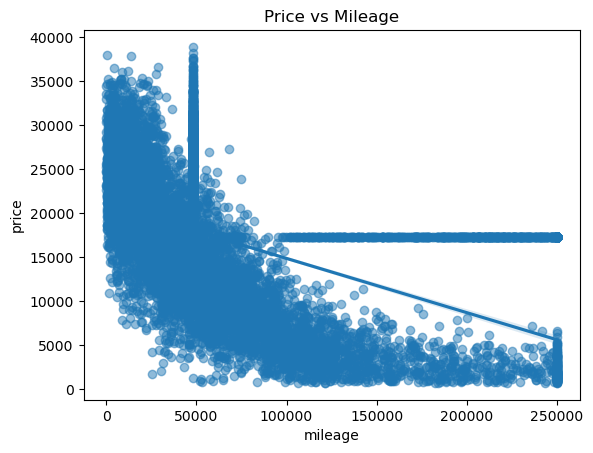

In [65]:
plt.figure()
sns.regplot(data=df, x="mileage", y="price", scatter_kws={"alpha":0.5})
plt.title("Price vs Mileage")
plt.show()


- Clear negative relationship between mileage and price.
- Lower mileage cars command higher prices.
- High mileage cars mostly lie in low-price segment.

- Premium brands like BMW, Mercedes, and Audi show higher median prices.
- Budget brands like Fiat and Dacia show lower median prices.

In [89]:
print("Most Common Brand:")
print(df["brand"].mode()[0])

print("Most Common Model:")
print(df["model"].mode()[0])

Most Common Brand:
Toyota
Most Common Model:
Model B


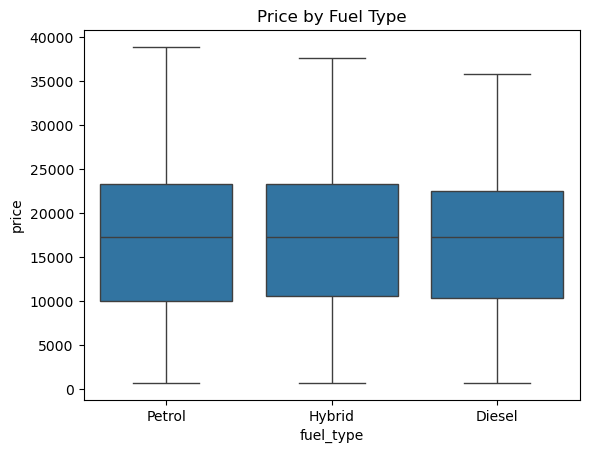

In [68]:
plt.figure()
sns.boxplot(data=df, x="fuel_type", y="price")
plt.title("Price by Fuel Type")
plt.show()


- median is consistent across all three fuel types. This suggests fuel type alone isn't the primary driver of the "typical" car price in this data.

- Petrol cars show the highest upper whisker indicating that the most expensive or high-performance models in this dataset are likely petrl based.

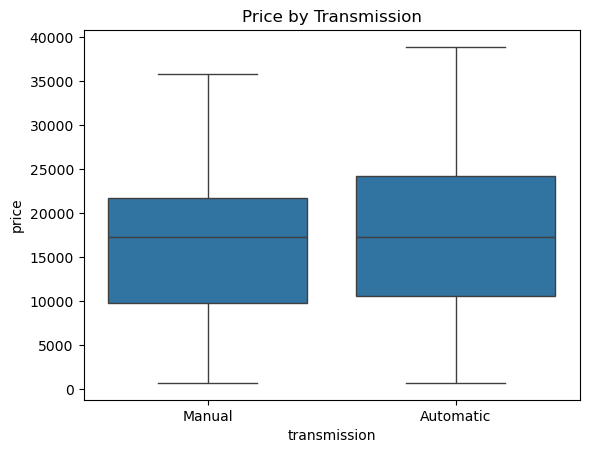

In [69]:
plt.figure()
sns.boxplot(data=df, x="transmission", y="price")
plt.title("Price by Transmission")
plt.show()


- median price for both is very similar, Automatic cars have a significantly higher upper quartile and maximum range.

C:\Users\Asus\AppData\Local\Temp\ipykernel_8580\1758793789.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mileage_price = df.groupby("mileage_group")["price"].mean().reset_index()


  mileage_group         price
0         0-20k  23312.934402
1       20k-40k  18400.351120
2       40k-60k  20047.486928
3       60k-80k  10586.675607
4      80k-100k   7875.710714
5     100k-150k   6418.006386
6         150k+  11171.601926


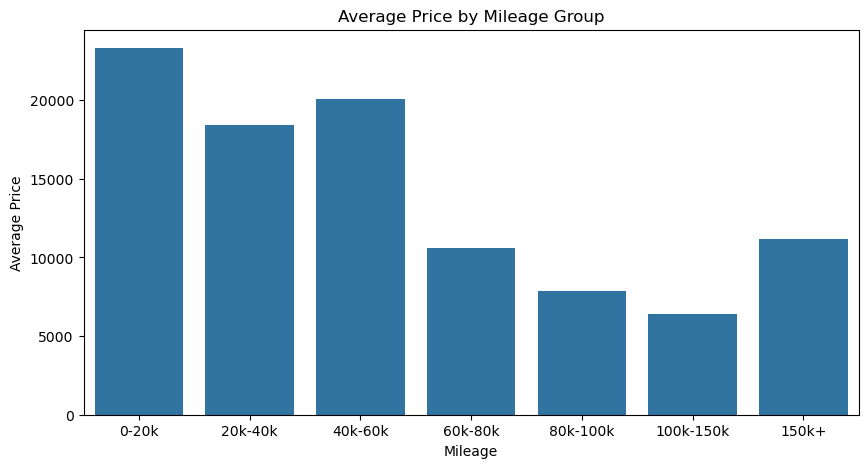

In [74]:
df["mileage_group"] = pd.cut(
    df["mileage"],
    bins=[0, 20000, 40000, 60000, 80000, 100000, 150000, 300000],
    labels=["0-20k","20k-40k","40k-60k","60k-80k","80k-100k","100k-150k","150k+"]
)

mileage_price = df.groupby("mileage_group")["price"].mean().reset_index()
print(mileage_price)

plt.figure(figsize=(10,5))
sns.barplot(data=mileage_price, x="mileage_group", y="price")
plt.title("Average Price by Mileage Group")
plt.xlabel("Mileage")
plt.ylabel("Average Price")
plt.show()

C:\Users\Asus\AppData\Local\Temp\ipykernel_8580\3816818730.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  combined = df.groupby(["age","mileage_group"])["price"].mean().reset_index()


    age mileage_group         price
0     1         0-20k  25577.569939
1     1       20k-40k  24748.137652
2     1       40k-60k  25340.588530
3     1       60k-80k           NaN
4     1      80k-100k           NaN
5     1     100k-150k           NaN
6     1         150k+           NaN
7     2         0-20k  22647.557841
8     2       20k-40k  21949.560976
9     2       40k-60k  22368.204188
10    2       60k-80k  11873.000000
11    2      80k-100k           NaN
12    2     100k-150k           NaN
13    2         150k+           NaN
14    3         0-20k  19487.375000
15    3       20k-40k  19097.487805
16    3       40k-60k  18566.226950
17    3       60k-80k  18233.333333
18    3      80k-100k           NaN
19    3     100k-150k           NaN


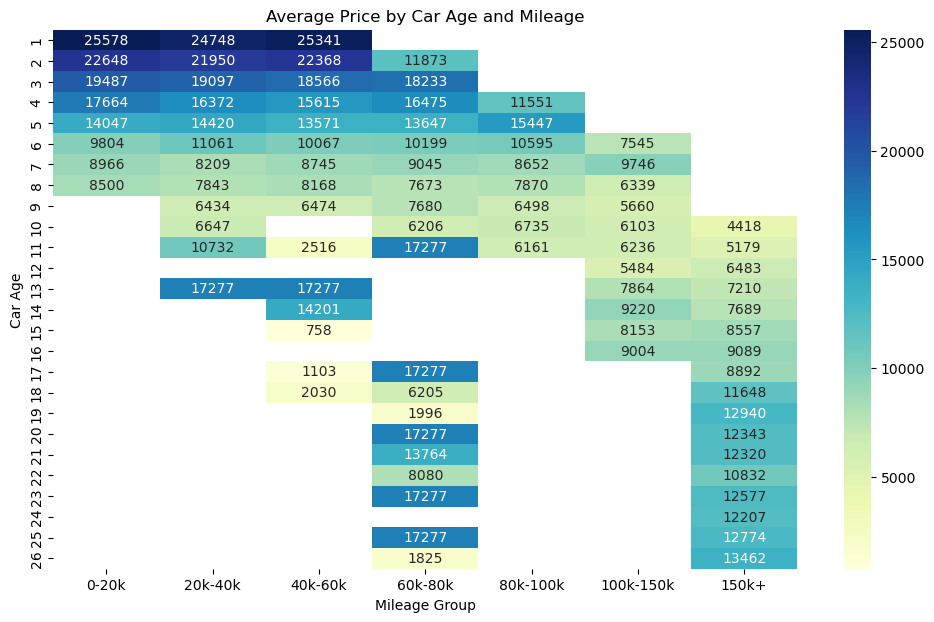

In [75]:
combined = df.groupby(["age","mileage_group"])["price"].mean().reset_index()
print(combined.head(20))

pivot_table = combined.pivot(index="age", columns="mileage_group", values="price")

plt.figure(figsize=(12,7))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Average Price by Car Age and Mileage")
plt.xlabel("Mileage Group")
plt.ylabel("Car Age")
plt.show()

The heatmap shows that newer cars with low mileage command the highest prices, while older cars with higher mileage sell for much less. Price declines sharply in early years, indicating strong depreciation, and age appears to influence price more strongly than mileage.

In [ ]:
# in the feature model, it is not metioned clearly that which one is the latest one and which one is the older,so checking it by using  group by

**as we can  see that all the model a , b and c are  of the latest models i.e of 2025, it means in the same year the same brand has launched has launched its model which is strange ,but according to this dataset:**
- BMW- its high resale price model is model A
- mercedes- model C
- audi- model A
- and other brand somehow shows the typical median price almost equal.

as these are the latest models so it should be asked that what could be the reason that they are listed in resale car list,it can be due to many factors like:
- customer behavior,he may have shifted to other vechile.
- he may be  not getting  the proper service of the company.
- he may not  be able to put up with the service cost.


**in the above chart the light colours represent  higher price and the dark colours lower price.**
- we can see that  BMW hybrid,mercedes hybrid,audi petrol has the highest price.
- Dacia-Diesel and Dacia-Petrol Tare very dark (almost black), meaning Dacia is the cheapest brand amongst all.

C:\Users\Asus\AppData\Local\Temp\ipykernel_8580\1221167720.py:12: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = filtered_df.pivot_table(


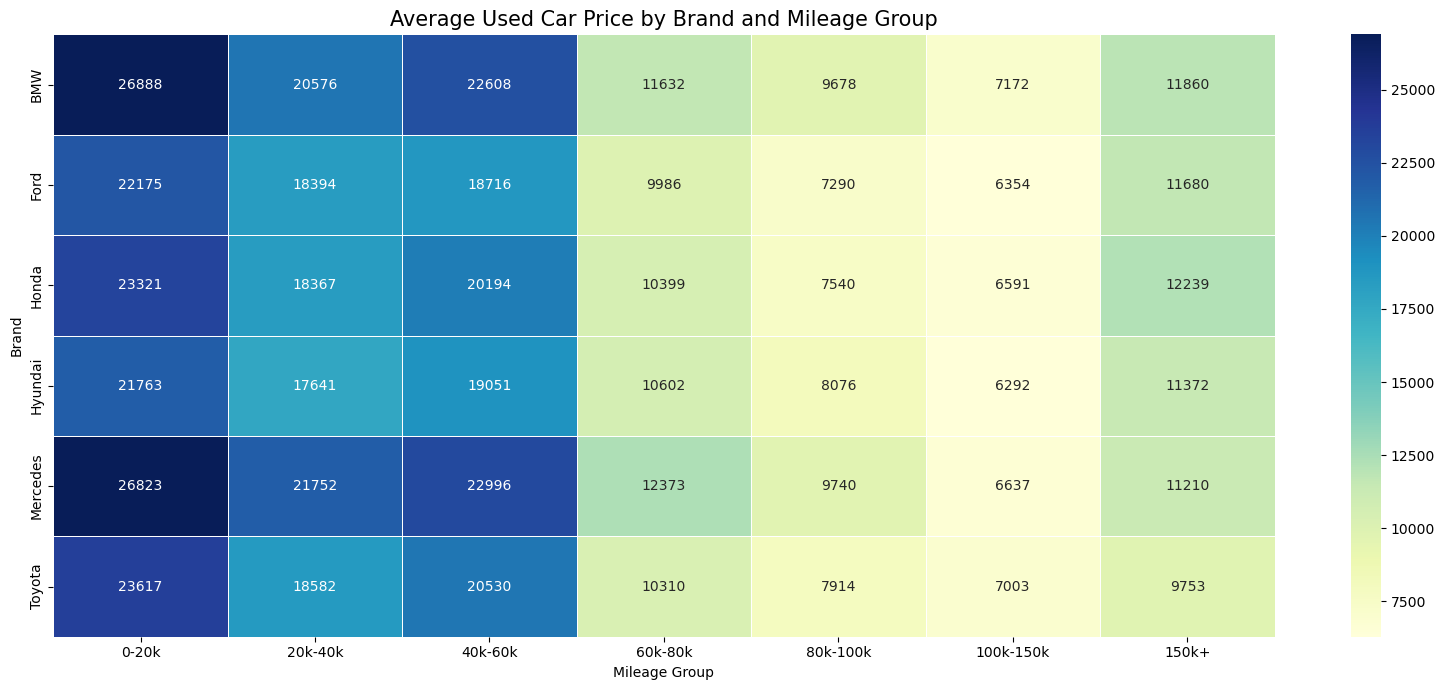

In [103]:
df["mileage_group"] = pd.cut(
    df["mileage"],
    bins=[0, 20000, 40000, 60000, 80000, 100000, 150000, 300000],
    labels=["0-20k","20k-40k","40k-60k","60k-80k","80k-100k","100k-150k","150k+"]
)

top_brands = df["brand"].value_counts().head(6).index
filtered_df = df[df["brand"].isin(top_brands)]


pivot = filtered_df.pivot_table(
    values="price",
    index="brand",
    columns="mileage_group",
    aggfunc="mean"
)


plt.figure(figsize=(16,7))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Average Used Car Price by Brand and Mileage Group", fontsize=15)
plt.xlabel("Mileage Group")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()

# Graphical understanding 

# Bar Chart → Cars by Brand

In [106]:
df['brand'].value_counts().head(10)

brand
Toyota      1438
Honda       1157
Mercedes     981
Ford         961
BMW          952
Hyundai      950
VW           911
Audi         804
Fiat         794
Dacia        693
Name: count, dtype: int64

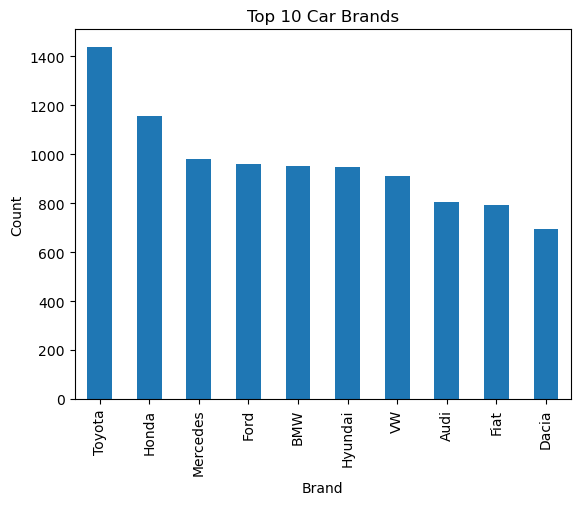

In [107]:
df['brand'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Car Brands")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.show()

# histogram-- price distribution

In [109]:
df['price'].describe()

count     9641.000000
mean     16735.123120
std       8332.819211
min        702.000000
25%      10171.000000
50%      17277.000000
75%      23155.000000
max      38875.000000
Name: price, dtype: float64

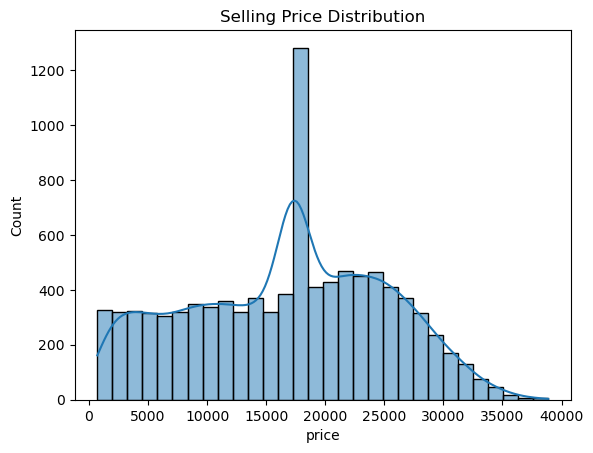

In [111]:
sns.histplot(df['price'], bins=30, kde=True)
plt.title("Selling Price Distribution")
plt.show()

# Scatter Plot - Price vs Kilometers Driven

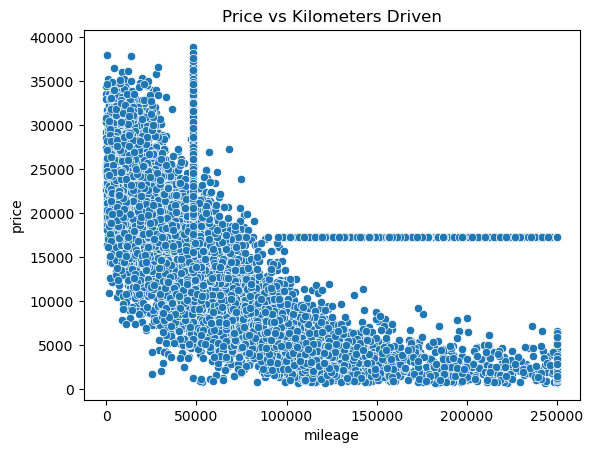

In [112]:
sns.scatterplot(x='mileage', y='price', data=df)
plt.title("Price vs Kilometers Driven")
plt.show()

# Box Plot - Price by Fuel Type

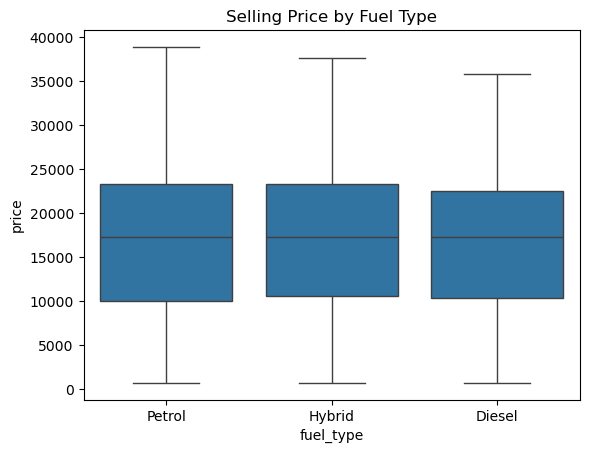

In [113]:
sns.boxplot(x='fuel_type', y='price', data=df)
plt.title("Selling Price by Fuel Type")
plt.show()

<Axes: xlabel='brand', ylabel='price'>

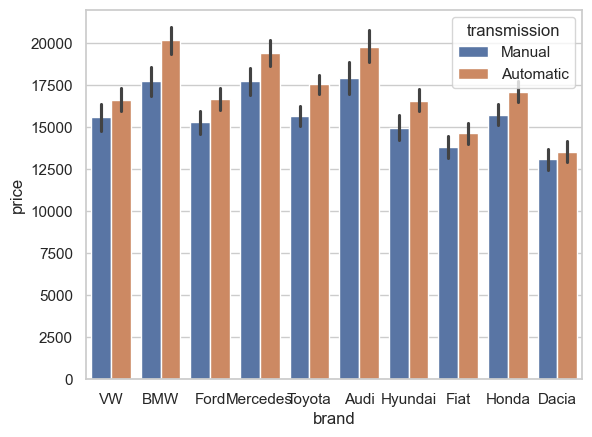

In [146]:
sns.barplot(data=df, x='brand', y='price', hue='transmission')

<Axes: xlabel='brand', ylabel='price'>

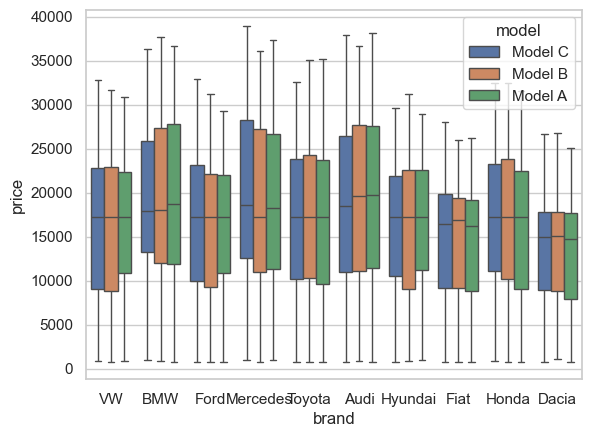

In [147]:
sns.boxplot(data=df, x='brand', y='price', hue='model')

<Axes: xlabel='transmission', ylabel='brand-fuel_type'>

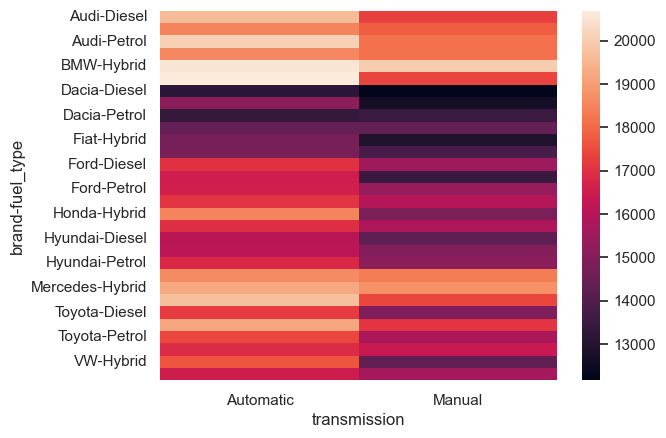

In [148]:
pivot = df.pivot_table(values='price',
                       index=['brand','fuel_type'],
                       columns='transmission',
                       aggfunc='mean')
sns.heatmap(pivot)

# Heatmap - Correlation

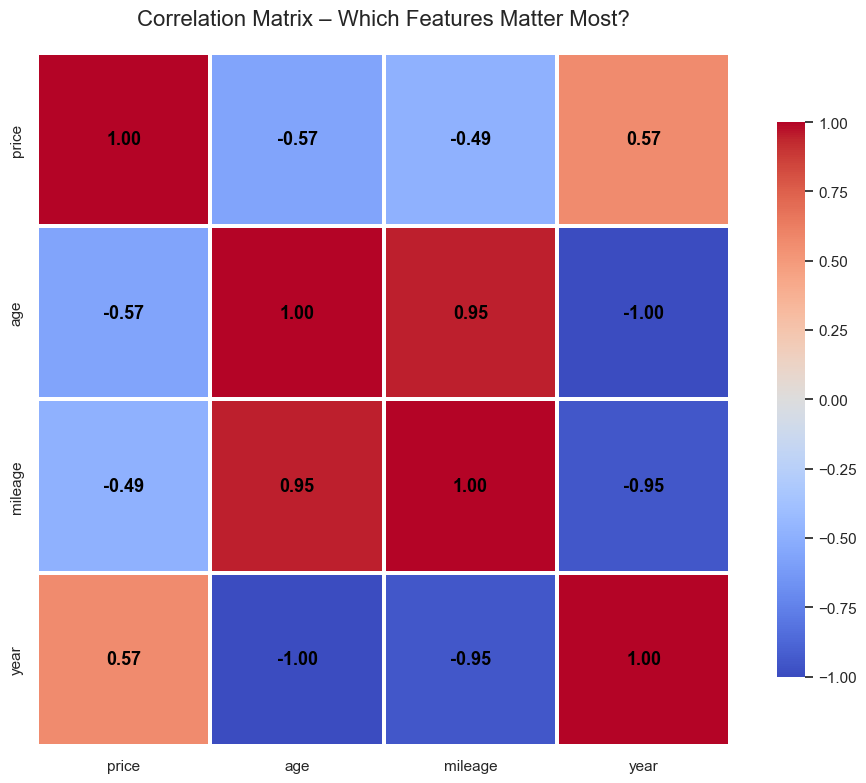


--- Correlation with Price ---
Age:     -0.569 (Lower price as age increases)
Mileage: -0.490 (Lower price as driven more)
Year:    0.569 (Higher price for newer models)


In [153]:

numeric_cols = ['price', 'age', 'mileage', 'year']
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))


sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            annot_kws={"size": 13, "weight": "bold", "color": "black"},
            cmap='coolwarm', 
            center=0, 
            square=True, 
            linewidths=1.5, 
            cbar_kws={"shrink": 0.8})

ax.set_title('Correlation Matrix – Which Features Matter Most?', fontsize=16, pad=20)

plt.tight_layout()
plt.show()

print("\n--- Correlation with Price ---")
print(f"Age:     {corr_matrix.loc['price', 'age']:.3f} (Lower price as age increases)")
print(f"Mileage: {corr_matrix.loc['price', 'mileage']:.3f} (Lower price as driven more)")
print(f"Year:    {corr_matrix.loc['price', 'year']:.3f} (Higher price for newer models)")

# Hypothesis 1: Lower KM Driven = Higher Price

In [117]:
corr = df['mileage'].corr(df['price'])
print("Correlation:", corr)

Correlation: -0.48981414715551425


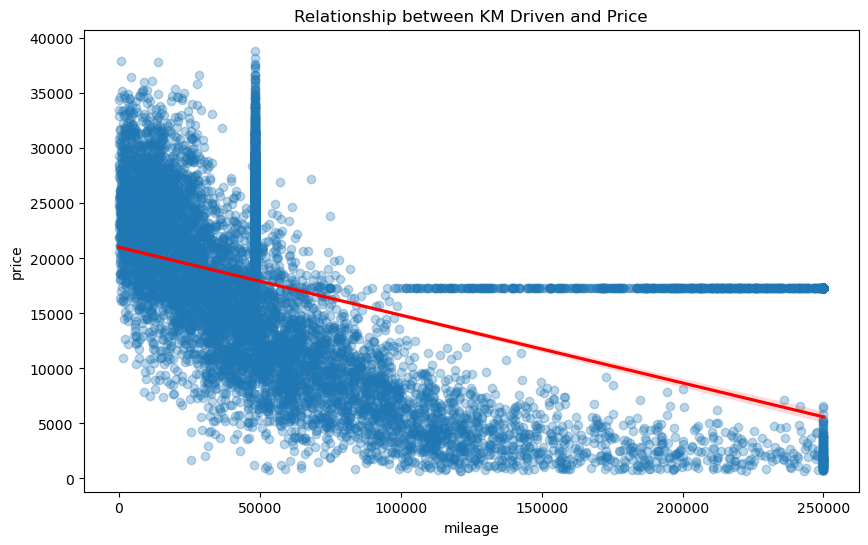

In [119]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='mileage', y='price', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title("Relationship between KM Driven and Price")
plt.show()

# Hypothesis 2: Diesel Cars Have Higher Resale Value

In [123]:
df.groupby('fuel_type')['price'].mean().sort_values(ascending=False)

fuel_type
Hybrid    17041.745203
Petrol    16753.683195
Diesel    16525.345704
Name: price, dtype: float64

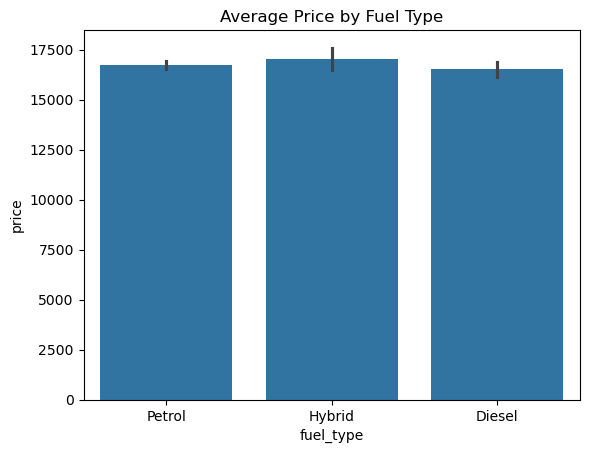

In [124]:
sns.barplot(x='fuel_type', y='price', data=df)
plt.title("Average Price by Fuel Type")
plt.show()

# Hypothesis 3: Newer Cars Cost More

In [125]:
df[['year','price']].corr()

,year,price
year,1.000000,0.568542
price,0.568542,1.000000


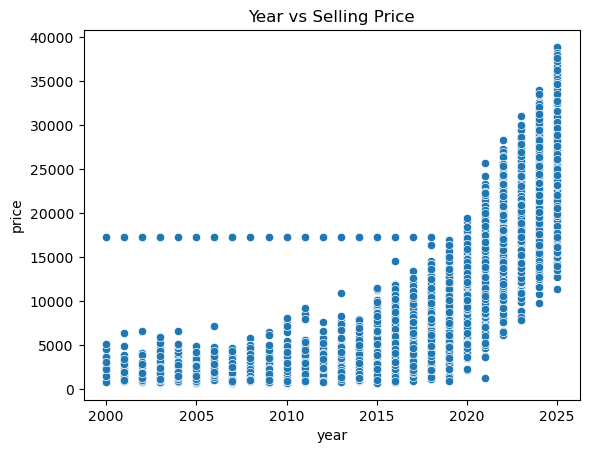

In [126]:
sns.scatterplot(x='year', y='price', data=df)
plt.title("Year vs Selling Price")
plt.show()

# Hypothesis 4: Premium Brands Cost More

In [128]:
df.groupby('brand')['price'].mean().sort_values(ascending=False).head(10)

brand
BMW         19187.134454
Audi        18983.764925
Mercedes    18788.451580
Toyota      16810.914465
Honda       16572.619706
VW          16235.744237
Ford        16102.683663
Hyundai     15938.627368
Fiat        14328.238035
Dacia       13348.307359
Name: price, dtype: float64

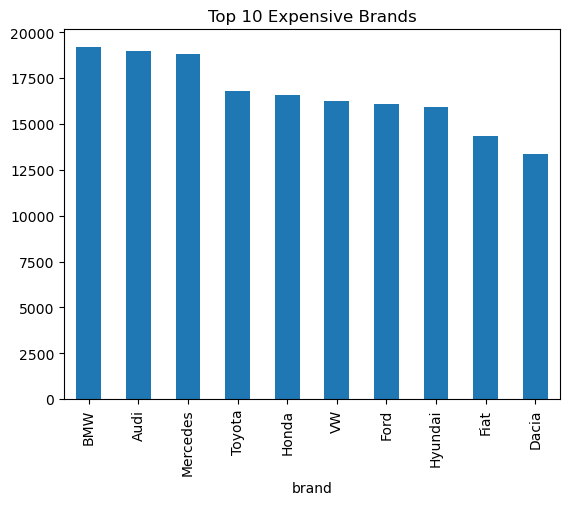

In [129]:
df.groupby('brand')['price'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Expensive Brands")
plt.show()

# automatic car cost high

Average Price by Transmission:
transmission
Automatic    17334.588757
Manual       15850.776637
Name: price, dtype: float64


C:\Users\Asus\AppData\Local\Temp\ipykernel_8580\394751048.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='transmission', y='price', palette='muted')


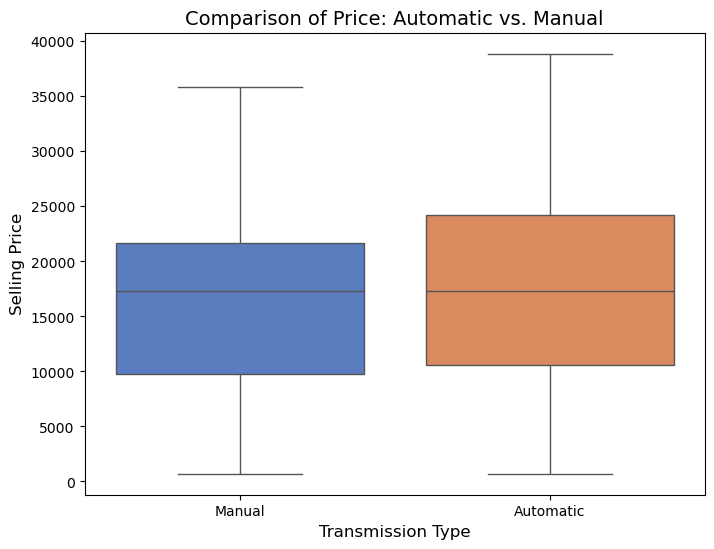

In [130]:
print("Average Price by Transmission:")
print(df.groupby('transmission')['price'].mean())


plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='transmission', y='price', palette='muted')


plt.title('Comparison of Price: Automatic vs. Manual', fontsize=14)
plt.xlabel('Transmission Type', fontsize=12)
plt.ylabel('Selling Price', fontsize=12)

plt.show()

# pattern

# Pattern 1: Older Cars Cheaper

In [134]:
df['age'] = 2026 - df['year']
df[['age','price']].corr()

,age,price
age,1.000000,-0.568542
price,-0.568542,1.000000


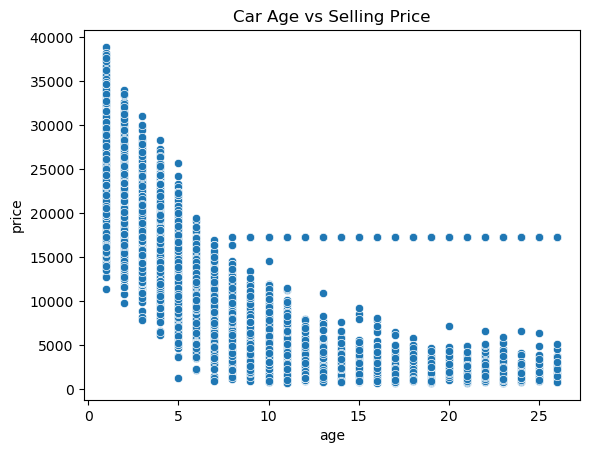

In [135]:
sns.scatterplot(x='age', y='price', data=df)
plt.title("Car Age vs Selling Price")
plt.show()

# Pattern 2 : Brand hierarchy-

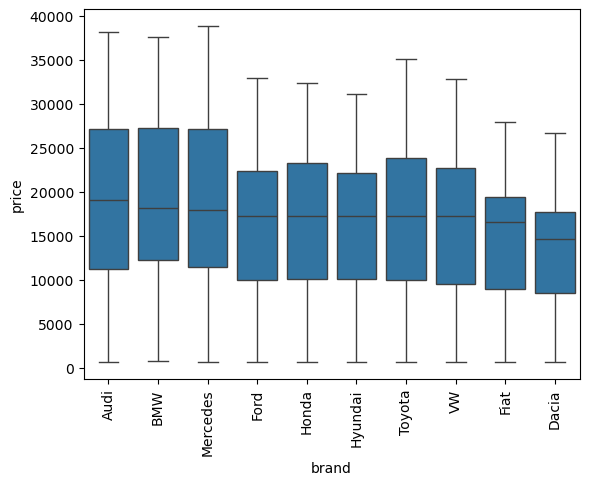

In [137]:
my_order = df.groupby("brand")["price"].median().sort_values(ascending=False).index

sns.boxplot(data=df, x='brand', y='price', order=my_order)
plt.xticks(rotation=90)
plt.show()


# pattern 3- transmission and age

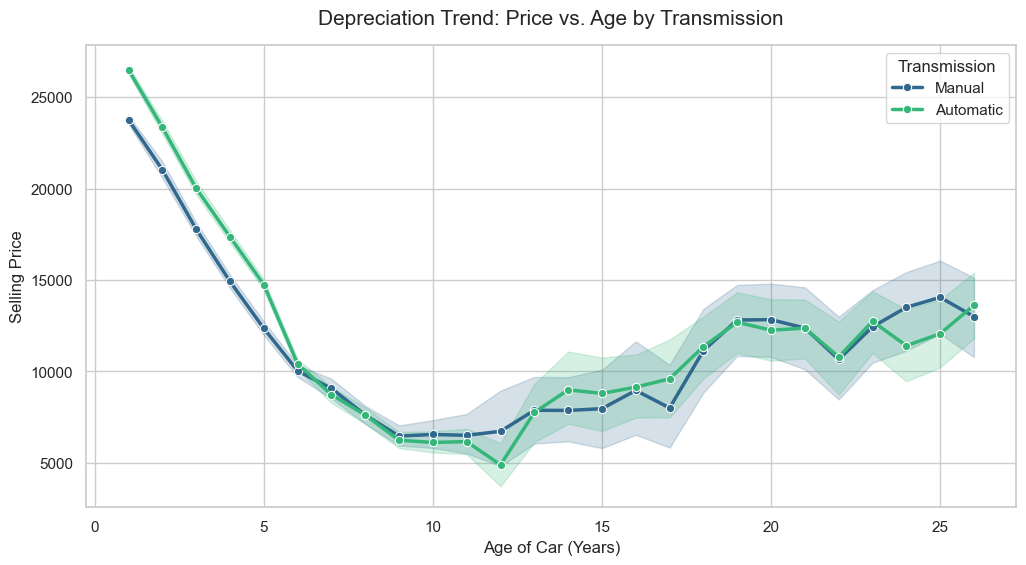

In [140]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))


sns.lineplot(data=df, x='age', y='price', hue='transmission', 
             marker='o', linewidth=2.5, palette='viridis')

# 3. Enhance the chart
plt.title('Depreciation Trend: Price vs. Age by Transmission', fontsize=15, pad=15)
plt.xlabel('Age of Car (Years)', fontsize=12)
plt.ylabel('Selling Price', fontsize=12)
plt.legend(title='Transmission')

plt.show()

# month

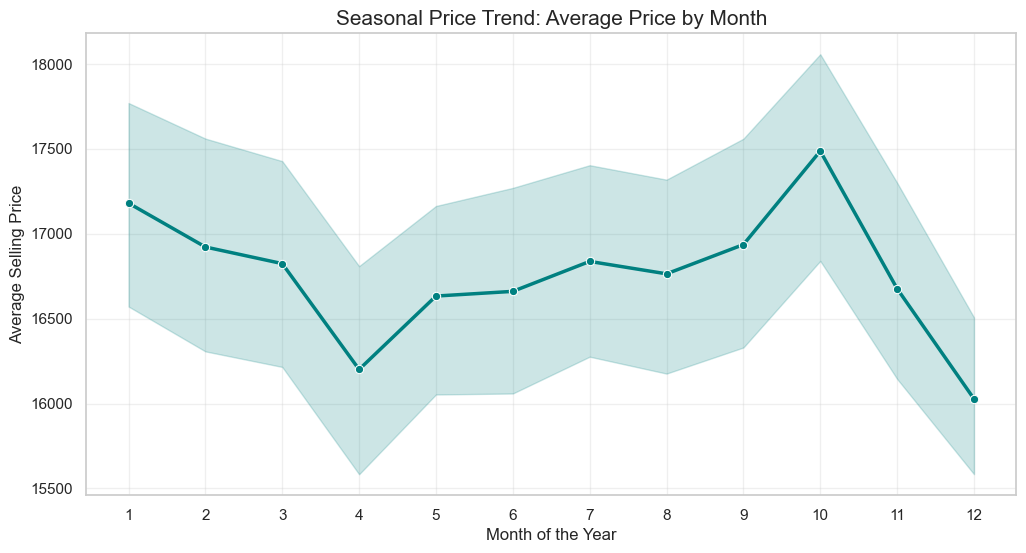

In [142]:
plt.figure(figsize=(12, 6))

sns.lineplot(data=df, x='sale_month', y='price', marker='o', color='teal', linewidth=2.5)

plt.title('Seasonal Price Trend: Average Price by Month', fontsize=15)
plt.xlabel('Month of the Year', fontsize=12)
plt.ylabel('Average Selling Price', fontsize=12)
plt.xticks(range(1, 13)) # Ensure all months 1-12 are shown
plt.grid(True, alpha=0.3)

plt.show()

In [ ]:
# Used Car Seller Dataset – Short Report

This project analyzes the used car seller dataset to understand the main factors that affect used car prices.

# Objective:
Study pricing trends in the used car market
Find factors affecting resale price

# Main Findings: 
- Older cars have lower prices.
- Cars with low mileage sell at higher prices.
- Popular brands have better resale value.
- hybrid fuel type charge high price.
- Automatic cars often sell at premium prices.
# Recommendations
For Buyers:
Prefer low mileage and good condition cars.
Verify documents and service history.
# For Sellers:
Maintain the car properly.
Set price based on market trends.
# Conclusion:

Used car prices depend mainly on age, mileage, brand, and condition. Proper data analysis helps buyers purchase wisely and sellers maximize profit.